# How bagging works:
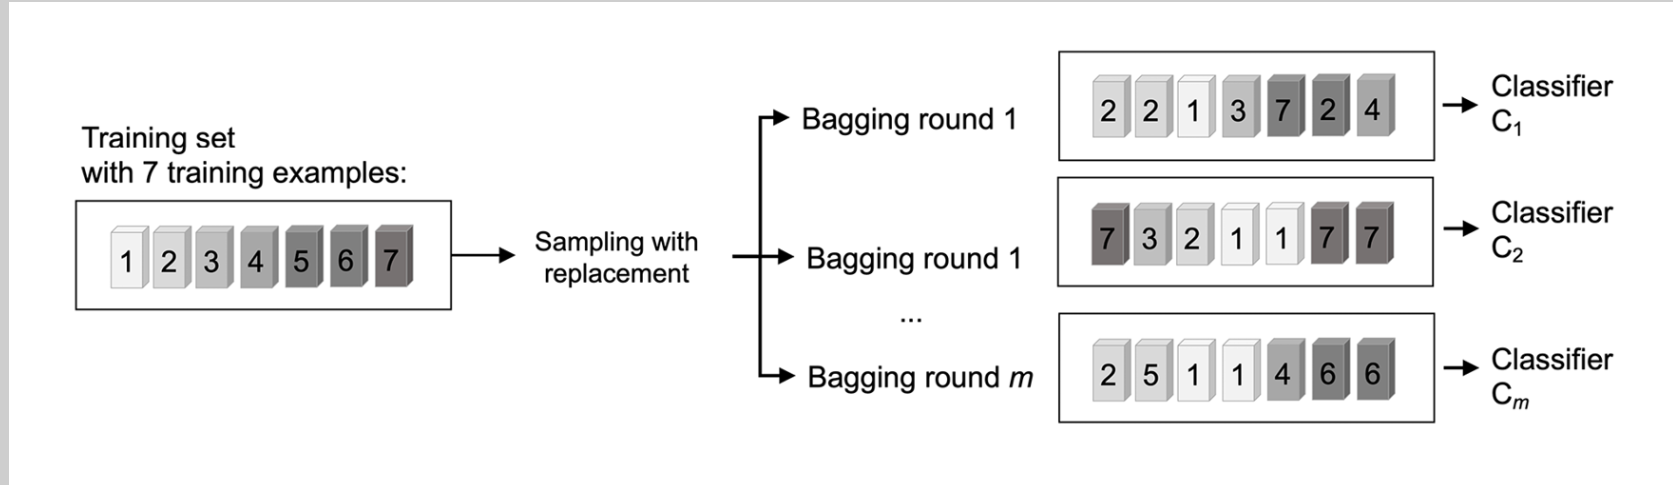
seven different training instances (denoted as indices 1-7)  are sampled randomly with replacement in each round of bagging. Each bootstrap sample is then used to fit a classifier, Cj

# Applying Bagging to Classify Examples in the Wine Datasets

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('https://archive.ics.uci.edu/ml/''machine-learning-databases''/wine/wine.data',header=None)

df.columns = ['Class label', 'Alcohol','Malic acid', 'Ash','Alcalinity of ash','Magnesium', 'Total phenols','Flavanoids', 'Nonflavanoid phenols','Proanthocyanins','Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']

df = df[df['Class label'] != 1]

y = df['Class label']

x =  df[['Alcohol', 'OD280/OD315 of diluted wines' ]]

le = LabelEncoder()

y = le.fit_transform(y)

x_train, x_test, y_train, y_test =  train_test_split(x,y, test_size= 0.2, stratify= y, random_state= 21)





# Lets implement the baggoing algorithm using the ensembler

In [2]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
tree =  DecisionTreeClassifier(criterion= "entropy", random_state= 21, max_depth= None)

bag = BaggingClassifier(estimator=tree, n_estimators= 500, max_samples= 1.0, max_features= 1.0, bootstrap= True, bootstrap_features= False, n_jobs=1, random_state= 21 )

#next Calculate the accuracy score of the prediction on training data and test datasets

tree = tree.fit(x_train, y_train)

y_train_pred = tree.predict(x_train)

y_test_pred = tree.predict(x_test)

train_tree = accuracy_score(y_train, y_train_pred)

test_tree  =  accuracy_score(y_test, y_test_pred)

print(f"The decision tree train/test accurcies is {train_tree} / {test_tree}")

#Based on output it overfits perhaps Bagging can help
bag = bag.fit(x_train, y_train)
y__train_pred = bag.predict(x_train)

y_test_pred = bag.predict(x_test)

train_tree = accuracy_score(y_train, y_train_pred)

tst_tree  =  accuracy_score(y_test, y_test_pred)

print(f"The Bagging tree train/test accurcies is {train_tree} / {tst_tree}")


The decision tree train/test accurcies is 1.0 / 0.875
The Bagging tree train/test accurcies is 1.0 / 0.875
